In [1]:
from deconvolawrence.meta_processing import *
from deconvolawrence import ms_plotter_tools as msp

# Automated deconvolution and quantification of mass spectra 
*Author - Lawrence Collins*

It is recommended to restart your computer before devconvolving large dataets (40+) as it is quite RAM intensive.
## Step 1: Load input file

Make sure to use double backslash. 
e.g. ``` path = "D:\\my mass spec folder\\my mass spec experiment\\mass_spec_input_file.xlsx" ```

### Setting up the input file

Sheet 1 of input file contains the directory folder of your mass spectra and the unidec configuration parameters. 

You can also add masses to detect and a corresponding colour. These are done by stipulating **Species** + *name* and **Color** + *name* in the Parameter column, followed by the desired mass or colour in the Input column.

A list of accepted colour names can be found [here](https://matplotlib.org/stable/gallery/color/named_colors.html)


**Example input directory**

| Parameter | Input | Comments |
| --- | --- |--- |
|Directory|D:\mass spec\protein labelling|
|Species Protein| 48127|
|Color Protein| orange|
|Start Scan|	490	|
|End Scan|540	|
|Tolerance (Da)	|10	|Peak matching tolerance |
|Config masslb	|15000|	Deconvolution window low mass|
|Config massub	|50000|	Deconvolution window high mass|
|Config massbins|	1|Mass bins for deconvolution - sample mass every|
|Config peakwindow|	10|	|
|Config peakthresh|0.05|	|
|Config minmz|	700|	m/z lower bounds (defaults to 0)|
|Config maxmz|		|m/z upper bounds (defaults to 10e12)|
|Config startz|	1	| |
|Config endz|	100	| |
|Config numz|	100	| |
|Config numit|	60	|number of iterations of deconvolution algorithm|

### Defining variables of different spectra

Each file within the directory can be linked to custom variables defined in a second sheet of the input directory. This comes in handy if wanting to filter data or perform analyses/comparison on subsets of your experiment. 

Any column names can be defined aside from 'Name' in column 0. Name corresponds to your filename (can be partial match).

Make sure var_ids=True ```load_input_file(var_ids = True)```  

**Example variables table**

|Name|	Peptide	|Catalyst|Time|
| --- | --- | --- | --- |
|240126 DoE Nexp 1	|1	|1	|1|
|240126 DoE Nexp 2	|2	|13	|3|
|240126 DoE Nexp 3	|1	|25	|3|
|240126 DoE Nexp 4	|3	|25	|1|
|240126 DoE Nexp 5	|2	|13	|5|
|240126 DoE Nexp 6	|3	|1	|3|
|240126 DoE Nexp 7	|3	|13	|1|
|240126 DoE Nexp 8	|2	|1	|5|
|240126 DoE Nexp 9	|1	|25	|5|




In [2]:
path = "Meta2_input_file_v3.xlsx" # path to input file
path = "Input_file_time_course.xlsx"


# path = "240308 DoE input file.xlsx"

eng = Meta2() # load engine

eng.load_input_file(path, unzip=False, clearhdf5=True, var_ids=True) # load input file and run deconvolution

eng.on_unidec() # run deconvolution


UniDec Engine v.6.0.4

UniDec Path: C:\Users\cm19ljc\Anaconda3\envs\deconvolawrence\lib\site-packages\unidec\bin\unidec.exe
Specified BAF has 718 spectra with line and profile data.
Specified BAF has 719 spectra with line and profile data.
Specified BAF has 716 spectra with line and profile data.
Specified BAF has 716 spectra with line and profile data.
Specified BAF has 724 spectra with line and profile data.
Specified BAF has 718 spectra with line and profile data.
Adding: 221018 LC113 100 mins_361014_BB4_01_89009.d to ms_dataset
Adding: 221018 LC113 15 mins_360986_BA6_01_88998.d to ms_dataset
Adding: 221018 LC113 30 mins_360987_BA7_01_89000.d to ms_dataset
Adding: 221018 LC113 45 mins_360989_BA8_01_89002.d to ms_dataset
Adding: 221018 LC113 60 mins_360990_BB1_01_89003.d to ms_dataset
Adding: 221018 LC113 80 mins_360991_BB2_01_89006.d to ms_dataset
Mass Grid Warning: (0,) (0,)
mz grid Warning: (0,) (0,)
Opening Time: 0.6045864999999999
masslb 40000
massub 45000
massbins 1
peakwindow

In [3]:
eng.results1

,Name,Time /mins,Label,Mass,Height,Color,Percentage_Labelling
0,221018 LC113 15 mins_360986_BA6_01_88998.d,15,MBP-LPETGVSEYG,41887.0,920.847595,green,23.234726
1,221018 LC113 15 mins_360986_BA6_01_88998.d,15,MBP-LPETGA,42334.0,3042.390625,blue,76.765266
2,221018 LC113 30 mins_360987_BA7_01_89000.d,30,MBP-LPETGVSEYG,41890.0,1891.636353,green,43.124054
3,221018 LC113 30 mins_360987_BA7_01_89000.d,30,MBP-LPETGA,42335.0,2494.863037,blue,56.875946
4,221018 LC113 45 mins_360989_BA8_01_89002.d,45,MBP-LPET,41299.0,136.946228,red,3.012704
5,221018 LC113 45 mins_360989_BA8_01_89002.d,45,MBP-LPETGVSEYG,41888.0,2508.631104,green,55.187820
6,221018 LC113 45 mins_360989_BA8_01_89002.d,45,MBP-LPETGA,42336.0,1900.047241,blue,41.799477
7,221018 LC113 60 mins_360990_BB1_01_89003.d,60,MBP-LPET,41288.0,246.187027,red,7.380663
8,221018 LC113 60 mins_360990_BB1_01_89003.d,60,MBP-LPETGVSEYG,41887.0,1918.923218,green,57.529129
9,221018 LC113 60 mins_360990_BB1_01_89003.d,60,MBP-LPETGA,42333.0,1170.457764,blue,35.090210


In [4]:
eng.results_df

,Name,Time /mins,MBP-LPET,MBP-LPETGA,MBP-LPETGVSEYG,MBP-LPET,MBP-LPETGA,MBP-LPETGVSEYG
0,221018 LC113 15 mins_360986_BA6_01_88998.d,15,0.000000,3042.390625,920.847595,0.000000,76.765266,23.234726
1,221018 LC113 30 mins_360987_BA7_01_89000.d,30,0.000000,2494.863037,1891.636353,0.000000,56.875946,43.124054
2,221018 LC113 45 mins_360989_BA8_01_89002.d,45,136.946228,1900.047241,2508.631104,3.012704,41.799477,55.187820
3,221018 LC113 60 mins_360990_BB1_01_89003.d,60,246.187027,1170.457764,1918.923218,7.380663,35.090210,57.529129
4,221018 LC113 80 mins_360991_BB2_01_89006.d,80,0.000000,1247.486694,2965.715088,0.000000,29.608995,70.391006
5,221018 LC113 100 mins_361014_BB4_01_89009.d,100,0.000000,1390.317627,3949.461914,0.000000,26.036987,73.963013


## Step 2: Plotting mass spectra

Mass spectra can be plotted separately and exported to *UniDec_Figures_and_Files* within your directory. 

### Useful commands

You can plot the deconvolved spectrum ```attr = "massdat"``` or the raw spectrum ```attr = "data2"``` (make sure to change the xlabel to m/z if plotting the raw spectrum ```xlabel = "m/z"```)

```window= [12000, 14000] ``` A mass window over which to plot over 

```legend = True``` to add a legend of the masses found within the spectra

```show_peaks = True``` to pick the peaks that correspond to defined species from the input file found in the spectrum

```fmt="svg"``` to plot in vector format (editable in photoshop) or ```fmt = 'png'``` for image files

### Combining spectra to a single figure 
Spectra can be stacked for nice made-for-publication figures. This can be combined with any defined variables within the second sheet of your input file to separate desired mass spectra to be stacked - e.g. if plotting a time course. 

To separate groups of spectra by variables from the second sheet of the input file into combined figures, define ```groupby = [variable_x]``` and ```combine = True``` (can be grouped by more than one variable by writing a list of variables into groupby).

In [11]:
spectra = eng.eng.data.spectra

# add in zoomed function that plots over window using min and max masses contained in masslist 
msp.plot_spectra_separate(spectra, attr = "massdat", xlabel = "Mass [Da]", 
                          export=True, c='black',lw=0.7,window=[None, None],
                         show_peaks=False,legend=False, directory =eng.directory, fmt='png') # fmt = 'svg' for vector format

msp.plot_spectra_separate(spectra, attr = "data2", xlabel = "m/z", export=True)


# eng.group_spectra("GVSEYG")

Fig exported to:  E:\WORK\example_time_course\UniDec_Figures_and_Files\221018 LC113 100 mins_361014_BB4_01_89009.d_massdat_img.png
Fig exported to:  E:\WORK\example_time_course\UniDec_Figures_and_Files\221018 LC113 15 mins_360986_BA6_01_88998.d_massdat_img.png
Fig exported to:  E:\WORK\example_time_course\UniDec_Figures_and_Files\221018 LC113 30 mins_360987_BA7_01_89000.d_massdat_img.png
Fig exported to:  E:\WORK\example_time_course\UniDec_Figures_and_Files\221018 LC113 45 mins_360989_BA8_01_89002.d_massdat_img.png
Fig exported to:  E:\WORK\example_time_course\UniDec_Figures_and_Files\221018 LC113 60 mins_360990_BB1_01_89003.d_massdat_img.png
Fig exported to:  E:\WORK\example_time_course\UniDec_Figures_and_Files\221018 LC113 80 mins_360991_BB2_01_89006.d_massdat_img.png
Fig exported to:  UniDec_Figures_and_Files\221018 LC113 100 mins_361014_BB4_01_89009.d_data2_img.svg
Fig exported to:  UniDec_Figures_and_Files\221018 LC113 15 mins_360986_BA6_01_88998.d_data2_img.svg
Fig exported to:  

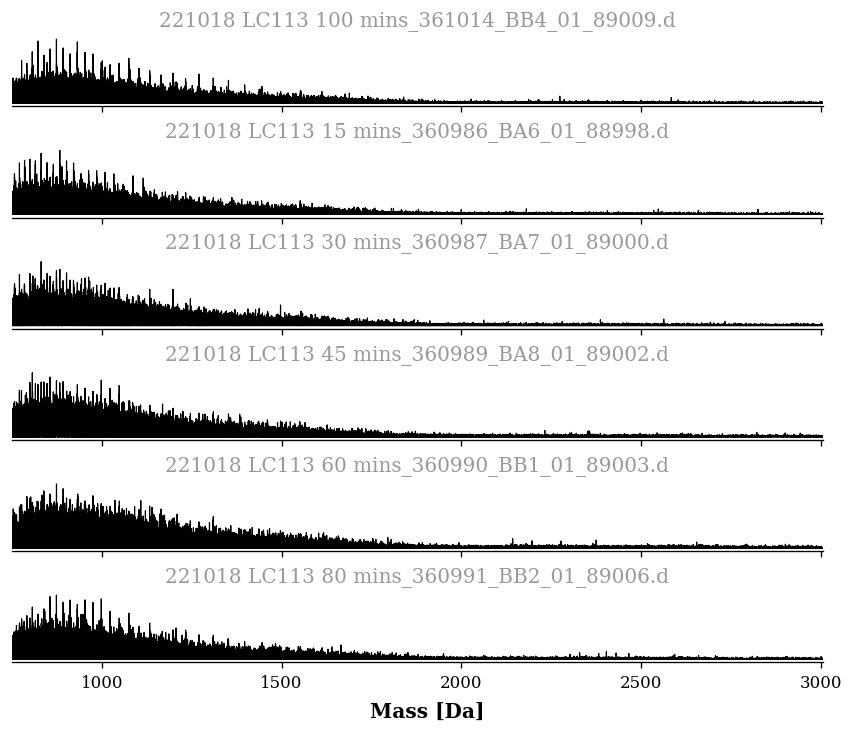

In [12]:
msp.plot_spectra_combined2(eng.eng.data.spectra, attr='data2', export = False, figsize=(7,6)) #change attr example

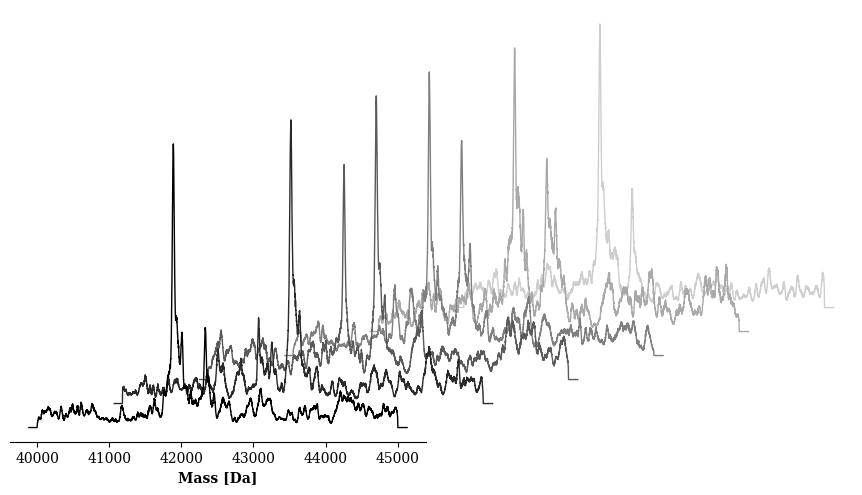

In [7]:
msp.plot_spectra_combined(eng.eng.data.spectra, export=False, show_peaks=False, show_titles=False, cmap='Greys_r')

In [1]:
eng.results1

NameError: name 'eng' is not defined

## Step 3: Quantification and analysis
A variety of useful statistical plotting tools taken from [Seaborn](https://seaborn.pydata.org/) and [Matplotlib](https://matplotlib.org/) can used to display your quantified data. Defined variables can be used to filter and select subsets of the data. 

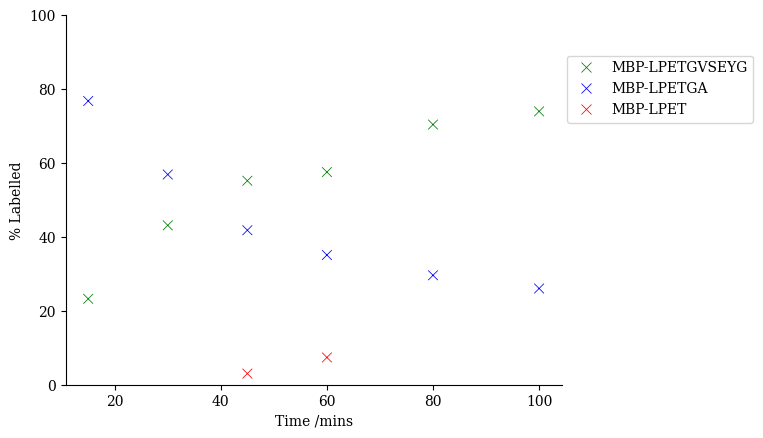

In [9]:
x="Time /mins"
y='Percentage_Labelling'
# on=['MBP-LPETGVSEYG', "MBP-LPET"]
# on_column='Label'
# on=None
# on_column=None
msp.plot_data(df=eng.results1, x=x, y=y, hue='Label',palette=eng.colors_dict, xlabel="Time /mins")
